[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/theochem/grid/blob/master/examples/Quickstart.ipynb)

# Halton Grid

This notebook demonstrates the use of the Halton low-discrepancy sequence
for numerical integration over a three-dimensional cubic domain.

The Halton sequence generates deterministic points in the unit cube
$[0, 1]^3$ using radical-inverse constructions based on successive prime
numbers.

## Constructing a Halton Grid

In [1]:
import numpy as np
from grid import Halton

grid = Halton(1000, 3)

print("Number of points:", grid.size)
print("Dimensions:", grid.points.shape[1])
print("First five points:")
print(grid.points[:5])
print("Sum of weights:", grid.weights.sum())

Number of points: 1000
Dimensions: 3
First five points:
[[0.5        0.33333333 0.2       ]
 [0.25       0.66666667 0.4       ]
 [0.75       0.11111111 0.6       ]
 [0.125      0.44444444 0.8       ]
 [0.625      0.77777778 0.04      ]]
Sum of weights: 1.0000000000000004


## Integrating a Function

As a simple example, consider the integral

$$
\int_{[0,1]^3} (x^2 + y^2 + z^2)\,dx\,dy\,dz.
$$

The exact value is $1$, since each squared coordinate contributes $1/3$.

In [2]:
values = np.sum(grid.points**2, axis=1)

estimate = grid.integrate(values)

print("Halton estimate:", estimate)
print("Exact value:", 1.0)
print("Absolute error:", abs(estimate - 1.0))

Halton estimate: 0.9959494573572703
Exact value: 1.0
Absolute error: 0.004050542642729749


## Comparing Different Dimensions

The same construction can be used directly in different dimensions.

In [3]:
for ndim in (1, 2, 3, 5):
    grid_nd = Halton(1000, ndim)
    print(f"{ndim}D grid shape: {grid_nd.points.shape}")

1D grid shape: (1000, 1)
2D grid shape: (1000, 2)
3D grid shape: (1000, 3)
5D grid shape: (1000, 5)


## Visualizing the Three-Dimensional Points

The first few thousand points can be visualized to illustrate the
distribution of the sequence throughout the unit cube.

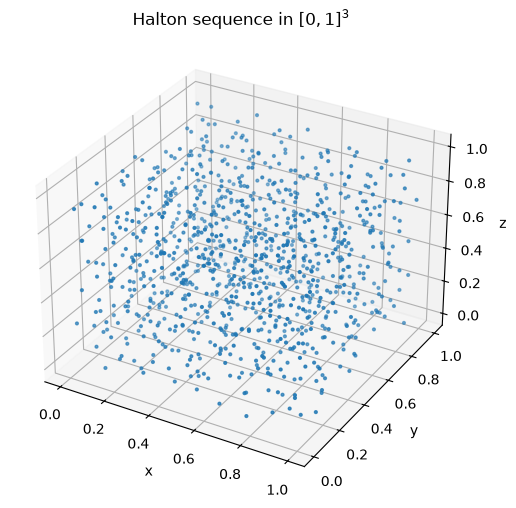

In [4]:
import matplotlib.pyplot as plt

grid_3d = Halton(1000, 3)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(projection="3d")

ax.scatter(
    grid_3d.points[:, 0],
    grid_3d.points[:, 1],
    grid_3d.points[:, 2],
    s=4,
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Halton sequence in $[0,1]^3$")

plt.show()

## Mapping to a Cubic Domain

The unit-cube construction can be mapped to any finite cubic domain.
For example, a point $(u,v,w)$ in $[0,1]^3$ can be mapped to
$[-1,1]^3$ using

$$
x = 2u - 1,\qquad
y = 2v - 1,\qquad
z = 2w - 1.
$$

The corresponding integration weights must be multiplied by the
Jacobian of the transformation.

In [5]:
unit_grid = Halton(1000, 3)

points = 2.0 * unit_grid.points - 1.0
weights = unit_grid.weights * 2.0**3

print("Mapped point range:")
print(points.min(axis=0), points.max(axis=0))
print("Sum of weights:", weights.sum())

Mapped point range:
[-0.99804688 -0.99908551 -0.99936   ] [0.99609375 0.99725652 0.9968    ]
Sum of weights: 8.000000000000004


## Summary

`Halton` provides a simple deterministic low-discrepancy sequence for
multidimensional integration. It can be constructed for an arbitrary
number of points and dimensions and can be mapped to other finite
hypercubic domains using standard coordinate transformations.

In [6]:
# compute the distance between the two atoms
R = np.linalg.norm(atcoords[0] - atcoords[1])

# Evaluate 1s orbitals (centered on each atom) on the entire grid points
s1_a_vals = np.sqrt(1 / np.pi) * np.exp(-np.linalg.norm(mgrid.points - atcoords[0], axis=1))
s1_b_vals = np.sqrt(1 / np.pi) * np.exp(-np.linalg.norm(mgrid.points - atcoords[1], axis=1))

# Calculate overlap integral analytically and numerically
S_ab = (1.0 + R + R**2 / 3) * np.exp(-R)
S_ab_num = mgrid.integrate(s1_a_vals * s1_b_vals)

print(f"Overlap integral (analytical): {S_ab}")
print(f"Overlap integral (numerical) : {S_ab_num}\n")

# Calculate normalization constant analytically and numerically
N = 1.0 / np.sqrt(2 + 2 * S_ab)
N_num = 1.0 / np.sqrt(mgrid.integrate((s1_a_vals + s1_b_vals) ** 2))

print(f"Normalization constant (analytical): {N}")
print(f"Normalization constant (numerical) : {N_num}\n")

# Build the wavefunction values on the grid points as a sum of 1s orbitals (centered on each atom)
psi_vals = N_num * (s1_a_vals + s1_b_vals)

# Compute the electron density and integrate it across all space
dens_vals = psi_vals**2
n_electrons = mgrid.integrate(dens_vals)
print(f"Integral of the electron density: {n_electrons} (expected to be 1)")

NameError: name 'atcoords' is not defined

### Interpolate Electron Density on the Grid

The [grid.interpolate](https://grid.qcdevs.org/pyapi/grid.molgrid.html#grid.molgrid.MolGrid.interpolate) functionality can be used to interpolate any scalar function at any point in space from evaluating the function on the grid points. Here, we use the electron density of $\mathrm{H}_{2}^{+}$ evaluated on the molecular grid to interpolate the electron density on a set of uniformly distributed points in the xy-plane (stored in `points` variable).


In [ ]:
# Sample points uniformly in the xy-plane (z=0)
x_grid = np.linspace(-3, 3, 100)
y_grid = np.linspace(-3, 3, 100)
x_grid, y_grid = np.meshgrid(x_grid, y_grid)
x_grid = x_grid.flatten()
y_grid = y_grid.flatten()
z_grid = np.zeros_like(x_grid)
points = np.array([x_grid, y_grid, z_grid]).T

# Interpolated electron density one the xy-plane
func_interpolation = mgrid.interpolate(dens_vals)
rho_iner = func_interpolation(points=points).reshape(100, 100)

# Create 3D Counterplot of the interpolated electron density
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111, projection="3d")

# Adjust the limits to fit your data
ax1.set_xlim((-3, 3))
ax1.set_ylim((-3, 3))
ax1.set_zlim((0, 0.1))

# Plot the interpolated electron density
ax1.plot_surface(x_grid.reshape(100, 100), y_grid.reshape(100, 100), rho_iner, cmap="viridis")

# Change the view angle, set labels and title
ax1.view_init(elev=20, azim=20)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Interpolated Electron Density")
ax1.set_title("Interpolated Electron Density for $H_2^+$ on XY Plane")
plt.show()

#### Check Interpolation Accuracy

Here we compare the interpolated density values in the xy-planes to the actual values computed by the analytical expression.


In [7]:
# Compute electron density on the xy-plane points analytically
s1_a_vals = np.sqrt(1 / np.pi) * np.exp(-np.linalg.norm(points - atcoords[0], axis=1))
s1_b_vals = np.sqrt(1 / np.pi) * np.exp(-np.linalg.norm(points - atcoords[1], axis=1))
psi_vals = N_num * (s1_a_vals + s1_b_vals)
rho = psi_vals**2

# Compute the electron density and integrate it across all space
rho_iner = func_interpolation(points=points)

print("Compare interpolated and analytical electron density")
print(f"Maximum Absolute Different: {np.max(np.abs(rho_iner - rho))}")

NameError: name 'atcoords' is not defined

### Differentiate Electron Density on the Grid

Given the value of a scalar function on the grid points, the [grid.interpolate](https://grid.qcdevs.org/pyapi/grid.molgrid.html#grid.molgrid.MolGrid.interpolate) can also be used to find the function derivative at any point in space. Here, we find the gradient of the electron density of $\mathrm{H}_{2}^{+}$ evaluated on a set of uniformly distributed points in a xy-plane (stored in `points` variable).


In [8]:
# Sample points uniformly in the xy-plane (z=0)
x_grid = np.linspace(-3, 3, 50)
y_grid = np.linspace(-3, 3, 50)
x_grid, y_grid = np.meshgrid(x_grid, y_grid)
x_grid = x_grid.flatten()
y_grid = y_grid.flatten()
z_grid = np.zeros_like(x_grid)
points = np.array([x_grid, y_grid, z_grid]).T

# Interpolated gradient of electron density one the xy-plane
grad_rho_iner = func_interpolation(points=points, deriv=1)

print("For each point, the gradient is a vector with 3 components")
print(f"Shape of the gradient array for {len(points)} points: {grad_rho_iner.shape}\n")
print(f"In a planar molecule, the gradient in the molecular plane should not have a z-component")
print(f"Maximum z-component of the interpolated gradient: {np.max(np.abs(grad_rho_iner[:, 2]))}")

NameError: name 'func_interpolation' is not defined

#### Check interpolated derivative accuracy

Check the accuracy of the gradient by comparing it to the analytical gradient computed by the analytical expression.


In [9]:
# Compute psi values analytically
s1_a_vals = np.sqrt(1 / np.pi) * np.exp(-np.linalg.norm(points - atcoords[0], axis=1))
s1_b_vals = np.sqrt(1 / np.pi) * np.exp(-np.linalg.norm(points - atcoords[1], axis=1))
psi_vals = N_num * (s1_a_vals + s1_b_vals)

# Compute the gradient of psi analytically
s1_a_grad = s1_a_vals[:, np.newaxis] * (points - atcoords[0])
s1_b_grad = s1_b_vals[:, np.newaxis] * (points - atcoords[1])
psi_grad = N_num * (s1_a_grad + s1_b_grad)

# Compute gradient of electron rho analytically
rho_grad = -2 * psi_vals[:, np.newaxis] * psi_grad

print("Compare interpolated and analytical electron density gradient")
print(f"Maximum Absolute Difference in any component: {np.max(np.abs(grad_rho_iner - rho_grad))}")
print(f"Mean Absolute Difference in any component: {np.mean(np.abs(grad_rho_iner - rho_grad))}")

NameError: name 'atcoords' is not defined

#### Graphical comparisons of the accuracy

Here, a graphical illustration is done to compare the accuracy of the interpolation of the derivative. It will be shown that the areas close to the nuclei have the largest errors.


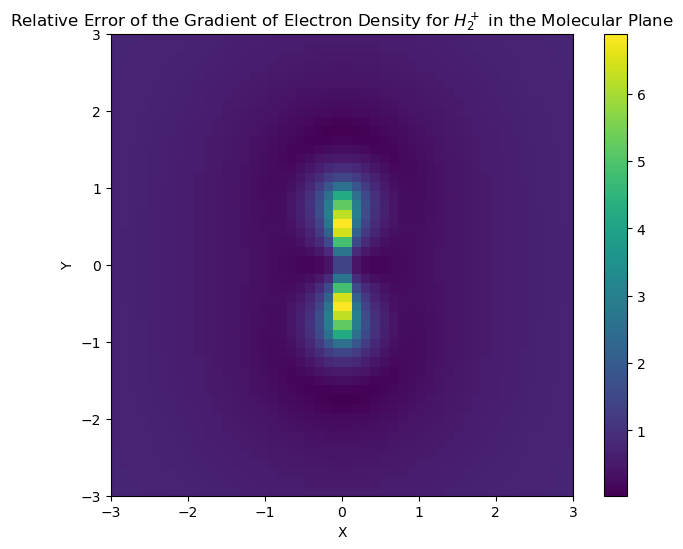

In [11]:
# compute the norm of the difference between the interpolated and analytical gradient
rho_error_norm = np.linalg.norm(grad_rho_iner - rho_grad, axis=1)
# divide by the norm of the analytical gradient
rho_error_norm /= np.linalg.norm(rho_grad, axis=1)

# create heatmap of the relative error
rho_error_norm = rho_error_norm.reshape(50, 50)
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)

# Adjust the limits to fit your data
ax1.set_xlim((-3, 3))
ax1.set_ylim((-3, 3))

# Plot the error heatmap
im = ax1.imshow(rho_error_norm, cmap="viridis", interpolation="none", extent=(-3, 3, -3, 3))
fig.colorbar(im)

# Set labels and title
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_title(
    "Relative Error of the Gradient of Electron Density for $H_2^+$ in the Molecular Plane"
)
plt.show()

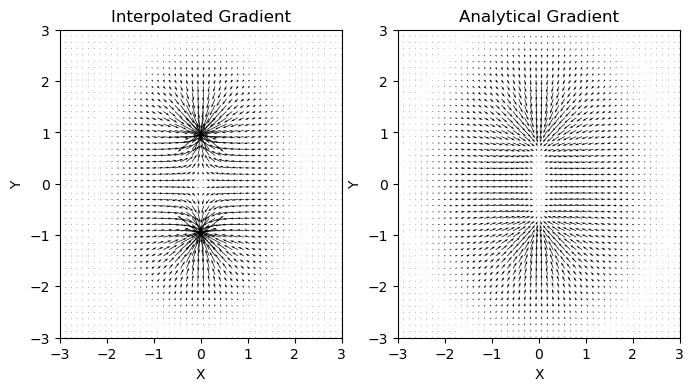

In [12]:
# Create vectorial map of the interpolated and the analytical gradient
fig = plt.figure(figsize=(8, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

# Plot the vectorial map (omit the z-component) of the interpolated gradient
ax1.quiver(points[:, 0], points[:, 1], grad_rho_iner[:, 0], grad_rho_iner[:, 1])
# Adjust the limits to fit your data and set labels and title
ax1.set_xlim((-3, 3))
ax1.set_ylim((-3, 3))
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_title("Interpolated Gradient")


# Plot the vectorial map (omit the z-component) of the analytical gradient
ax2.quiver(points[:, 0], points[:, 1], rho_grad[:, 0], rho_grad[:, 1])
# Adjust the limits to fit your data and set labels and title
ax2.set_xlim((-3, 3))
ax2.set_ylim((-3, 3))
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_title("Analytical Gradient")

plt.show()